# Word Analysis Pilot
This notebook loads the V2 gender-extracted dataset and runs mini pilots on word association

In [1]:
import pandas as pd
import spacy
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
from wordcloud import WordCloud
import math

nlp = spacy.load("en_core_web_sm")

# Load the gender-extracted dataset
df = pd.read_csv('../../data/snippets/total_snippets_with_gender.csv')

# We focus on clearly attributed Male and Female rows for this analysis
BINARY = ['Male', 'Female']
df_binary = df[df['Assigned_Gender'].isin(BINARY)].copy()

print(f"Male snippets: {(df_binary['Assigned_Gender']=='Male').sum()}")
print(f"Female snippets: {(df_binary['Assigned_Gender']=='Female').sum()}")
print(f"Total for analysis: {len(df_binary)}")


Male snippets: 2713
Female snippets: 984
Total for analysis: 3697


In [2]:
def extract_words_near_keyword(row, window=30, use_weighting=True):
    """
    Improved word extraction with:
    1. Sentence-aware windowing: prefer words in the same sentence as keyword
    2. Distance weighting: words closer to the keyword get higher weight
    
    Returns: dict of {POS: Counter(word -> weighted_count)}
    """
    text = str(row['Snippet'])
    keyword = str(row['Keyword']).lower()
    doc = nlp(text)
    
    # Find keyword token
    kw_token = next(
        (t for t in doc if keyword in t.lemma_.lower() and t.pos_ != 'PROPN'), None
    )
    if not kw_token:
        return {'ADJ': Counter(), 'NOUN': Counter(), 'VERB': Counter()}
    
    kw_idx = kw_token.i
    
    # --- Find the sentence containing the keyword ---
    kw_sent = kw_token.sent
    sent_start = kw_sent.start
    sent_end = kw_sent.end
    
    # Optionally expand to ±1 sentence for more context
    # (comment out if you only want same-sentence words)
    for sent in doc.sents:
        if sent.end == sent_start:
            sent_start = sent.start  # include previous sentence
        if sent.start == sent_end:
            sent_end = sent.end      # include next sentence
    
    # Further constrain by the fixed token window
    start = max(sent_start, kw_idx - window)
    end = min(sent_end, kw_idx + window)
    
    words = {'ADJ': Counter(), 'NOUN': Counter(), 'VERB': Counter()}
    
    for i in range(start, end):
        tok = doc[i]
        if len(tok.text) <= 3 or not tok.is_alpha or tok.is_stop:
            continue
        pos = tok.pos_
        if pos not in words:
            continue
        
        lemma = tok.lemma_.lower()
        
        if use_weighting:
            distance = abs(i - kw_idx)
            weight = max(0.05, 1.0 - (distance / window))  # linear decay, min 0.05
        else:
            weight = 1.0
        
        words[pos][lemma] += weight
    
    return words


In [3]:
df_binary['Words'] = df_binary.apply(
    lambda row: extract_words_near_keyword(row, window=30, use_weighting=True), 
    axis=1
)

In [4]:
# Aggregate weighted word counts by gender and POS
gender_words = {
    'Male': {'ADJ': Counter(), 'NOUN': Counter(), 'VERB': Counter()},
    'Female': {'ADJ': Counter(), 'NOUN': Counter(), 'VERB': Counter()}
}

for _, row in df_binary.iterrows():
    gender = row['Assigned_Gender']
    word_data = row['Words']
    
    for pos in ['ADJ', 'NOUN', 'VERB']:
        gender_words[gender][pos].update(word_data[pos])

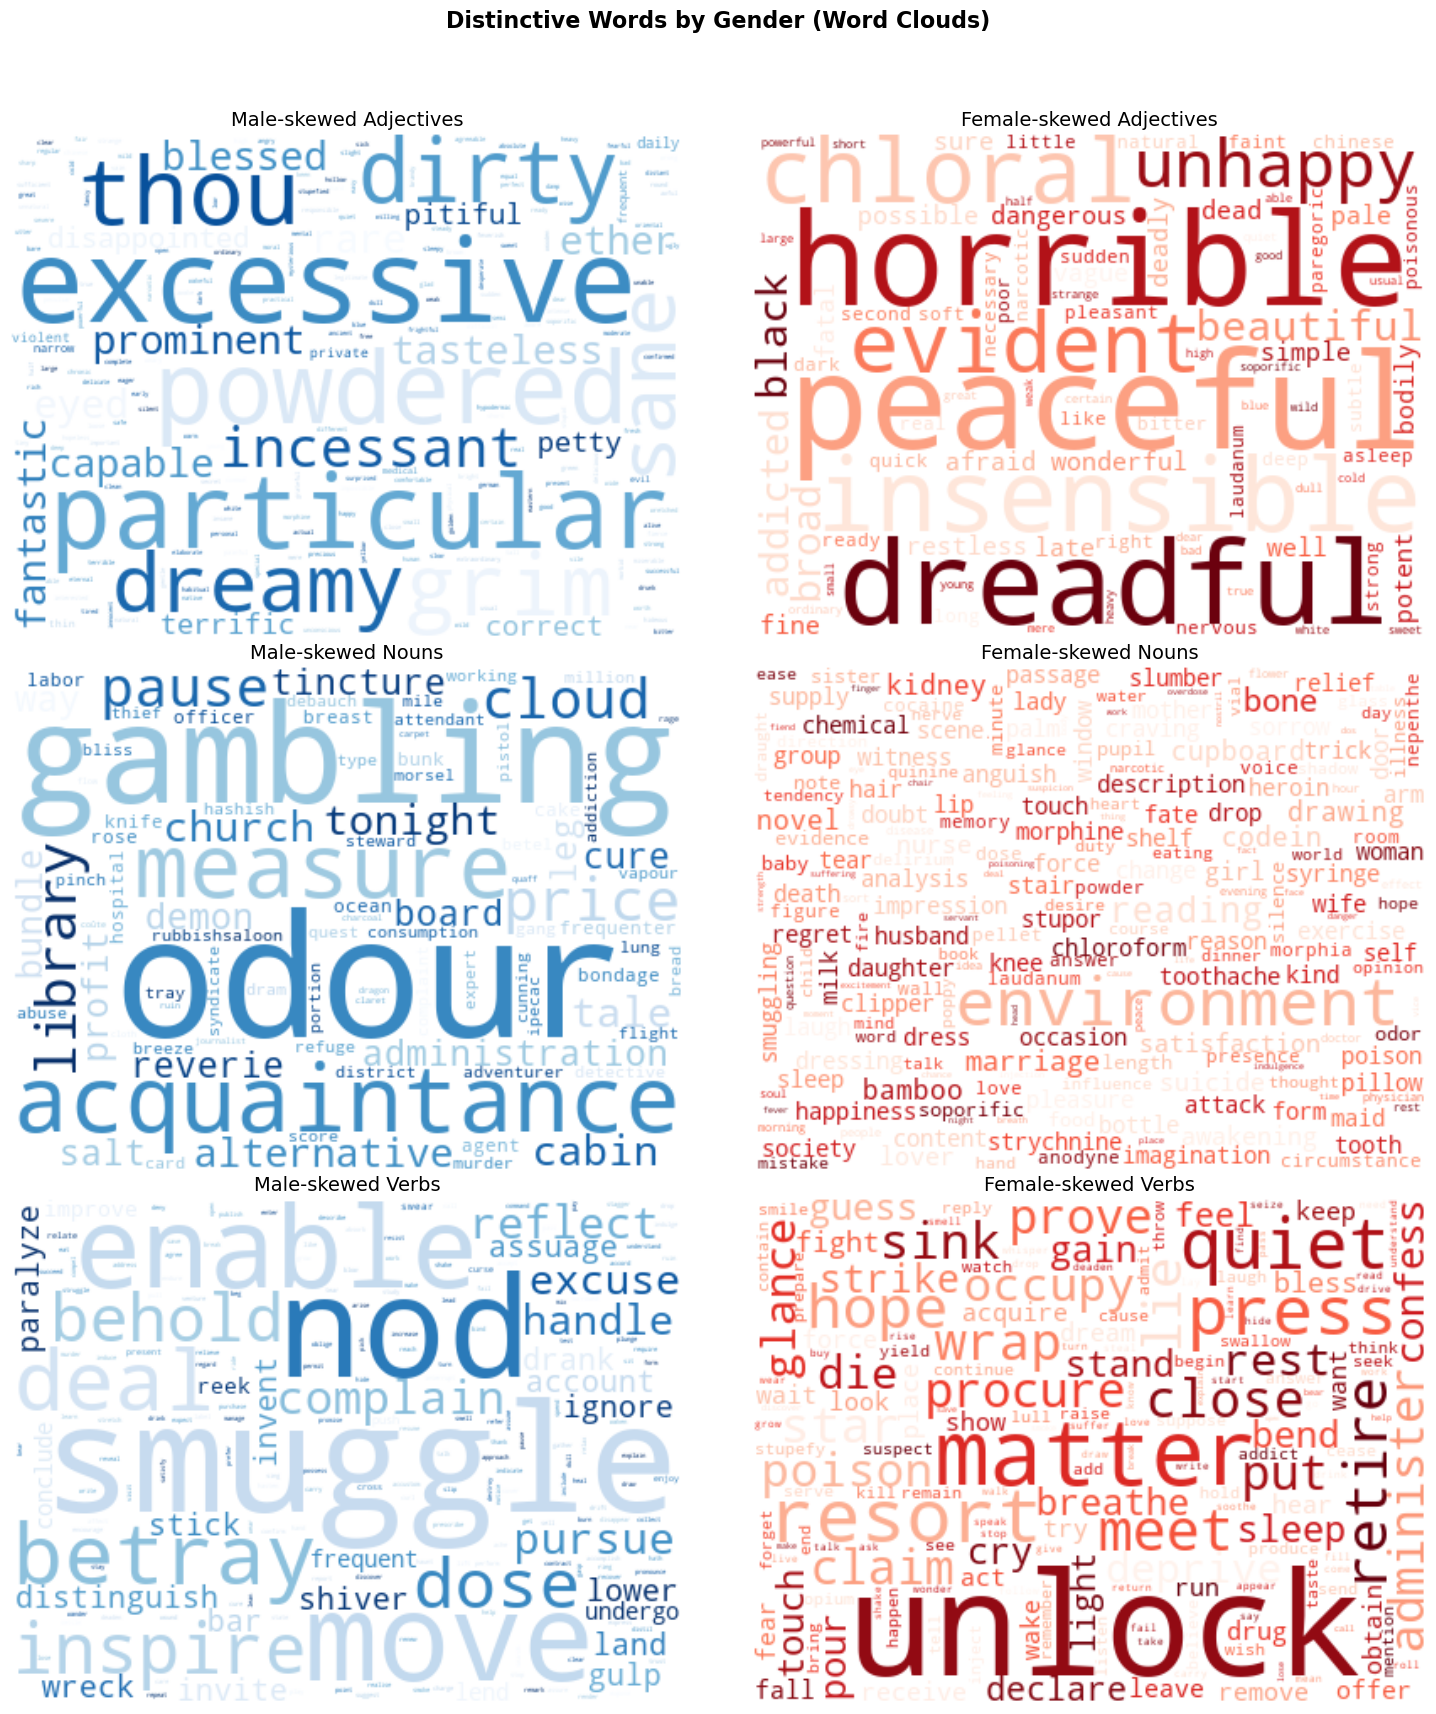

Word clouds saved to ../../data/snippets/wordclouds_by_gender.png


In [5]:
def get_distinctive_words(male_counter, female_counter, min_count=3):
    all_words = set(list(male_counter.keys()) + list(female_counter.keys()))
    male_total = sum(male_counter.values()) or 1
    female_total = sum(female_counter.values()) or 1
    
    distinctly_male = {}
    distinctly_female = {}
    
    for w in all_words:
        m_freq = male_counter[w] / male_total
        f_freq = female_counter[w] / female_total
        
        if male_counter[w] >= min_count:
            distinctly_male[w] = m_freq / max(f_freq, 1e-6)
        if female_counter[w] >= min_count:
            distinctly_female[w] = f_freq / max(m_freq, 1e-6)
            
    return distinctly_male, distinctly_female

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('Distinctive Words by Gender (Word Clouds)', fontsize=16, fontweight='bold')

pos_labels = ['ADJ', 'NOUN', 'VERB']
pos_titles = ['Adjectives', 'Nouns', 'Verbs']

for i, pos in enumerate(pos_labels):
    m_distinct, f_distinct = get_distinctive_words(gender_words['Male'][pos], gender_words['Female'][pos])
    
    wc_m = WordCloud(width=400, height=300, background_color='white', colormap='Blues').generate_from_frequencies(m_distinct)
    axes[i, 0].imshow(wc_m, interpolation='bilinear')
    axes[i, 0].set_title(f'Male-skewed {pos_titles[i]}', fontsize=14)
    axes[i, 0].axis('off')
    
    wc_f = WordCloud(width=400, height=300, background_color='white', colormap='Reds').generate_from_frequencies(f_distinct)
    axes[i, 1].imshow(wc_f, interpolation='bilinear')
    axes[i, 1].set_title(f'Female-skewed {pos_titles[i]}', fontsize=14)
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('../../data/snippets/wordclouds_by_gender.png', dpi=150)
plt.show()

print("Word clouds saved to ../../data/snippets/wordclouds_by_gender.png")


Observation:
* The Male cluster is _transactional and abstract_. It focuses on the "price" and "administration" of the "tincture," the "gambling" and "trade" of the drug world, and the intellectual "reverie" or "dreamy" states of the user. It treats opium as an object of study or a commodity.
* The Female cluster is _bodily_ and _situational_. It focuses on the "environment" of "marriage," the physical reality of the "bone" and "syringe," and the emotional weight of being "insensible," "wistful," or "dreadful." It treats opium as a lived—and often hidden—domestic crisis.

In [7]:
def show_snippets_for_word(df, target_word, pos='ADJ', gender=None, num_samples=5):
    """
    Prints examples of snippets where the target_word was extracted.
    - target_word: The word you are curious about (e.g., 'cruel')
    - pos: The part of speech ('ADJ', 'NOUN', or 'VERB')
    - gender: Optional filter ('Male' or 'Female')
    """
    print(f"--- Snippets containing the {pos} '{target_word}' ---")
    
    # Filter by gender if specified
    if gender:
        df_sub = df[df['Assigned_Gender'] == gender]
    else:
        df_sub = df
        
    # Find rows where the target_word is in the extracted words for the given POS
    def contains_word(words_dict):
        if isinstance(words_dict, dict) and pos in words_dict:
            return target_word.lower() in words_dict[pos]
        return False
        
    mask = df_sub['Words'].apply(contains_word)
    matched_df = df_sub[mask]
    
    print(f"Total occurrences found: {len(matched_df)}\n")
    
    # Print the examples
    for idx, row in matched_df.head(num_samples).iterrows():
        print(f"[{row['Assigned_Gender']}] - Keyword: {row['Keyword']}")
        print(f"Snippet: {row['Snippet']}")
        print("-" * 80)

In [12]:
show_snippets_for_word(df_binary, target_word='odour', pos='NOUN', gender='Male')

--- Snippets containing the NOUN 'odour' ---
Total occurrences found: 15

[Male] - Keyword: opium
Snippet: his head buried in his arms, a sailor sprawled over a table, and by the tawdrily painted bar that ran across one complete side stood two haggard women, mocking an old man who was brushing the sleeves of his coat with an expression of disgust. “He thinks he’s got red ants on him,” laughed one of them, as Dorian passed by. The man looked at her in terror and began to whimper. At the end of the room there was a little staircase, leading to a darkened chamber. As Dorian hurried up its three rickety steps, the heavy odour of opium met him. He heaved a deep breath, and his nostrils quivered with pleasure. When he entered, a young man with smooth yellow hair, who was bending over a lamp lighting a long thin pipe, looked up at him and nodded in a hesitating manner. “You here, Adrian?” muttered Dorian. “Where else should I be?” he answered, listlessly. “None of the chaps will speak to me n

In these male snippets, "odour" serves as a _"sensory portal"_. In the example of the Detective/Lawyer: It is a "bitter, vapid taste" that alerts the lawyer to the presence of opium. It’s a clue to be decoded. For the aesthetician (Dorian Gray): The "heavy odour" is met with "pleasure." Also there's the snippet where the "odour of propre linen" mingles with "opium and cologne." 

In [11]:
show_snippets_for_word(df_binary, target_word='environment', pos='NOUN', gender='Female')

--- Snippets containing the NOUN 'environment' ---
Total occurrences found: 4

[Female] - Keyword: soporific
Snippet: all of which he pleasured greatly, without thought of the Life Force palpitating beneath and in spite of Bernard Shaw--in whom he believed. Loretta burgeoned. She swiftly developed personality. She discovered a will of her own and wishes of her own that were not everlastingly entwined with the will and the wishes of Daisy. She was petted by Jack Hemingway, spoiled by Alice Hemingway, and devotedly attended by Ned Bashford. They encouraged her whims and laughed at her follies, while she developed the pretty little tyrannies that are latent in all pretty and delicate women. Her environment acted as a soporific upon her ancient desire always to live with Daisy. This desire no longer prodded her as in the days of her companionship with Billy. The more she saw of Billy, the more certain she had been that she could not live away from Daisy. The more she saw of Ned Bashford, t

"Environment" in the female snippets is used as a _metaphor for social entrapment_. One snippet explicitly says her "environment acted as a soporific." This is a sophisticated literary move: the author is saying that society itself is the drug that keeps women sleepy and compliant.

In [10]:
show_snippets_for_word(df_binary, target_word='unlock', pos='VERB', gender='Female')

--- Snippets containing the VERB 'unlock' ---
Total occurrences found: 6

[Female] - Keyword: opium
Snippet: feeling, not new, but strange from its intensity, took possession of her, steeping her soul in bliss, a feeling that made her both tremble and be glad. She thought no more of the lonely grave, but of an angel in ecstasy, an angel in heaven. She looked around, she raised her eyes to the altar, she tried to seize upon some idea which should continue with her, and be a key with which she could unlock this fountain of joy hereafter when she would. She almost felt for the moment as if it would be worthy to grovel for such opium at the knees of an oleosaccharine priest and contribute to his support forever. She tried to think of something to which to compare the feeling, but in vain. In the effort to fix it her mind and memory became a blank, and for a blissful interval she could not think, she could only feel. Then came the inevitable moment of grateful acknowledgment when her senses

For women, the verb "unlock" is almost always tied to _gendered furniture_. Women aren't going to a "den" in these snippets; they are "unlocking" a supply hidden within the home (in the dressing-case/ the cupboard / the bag)

In [13]:
show_snippets_for_word(df_binary, target_word='bone', pos='NOUN', gender='Female')

--- Snippets containing the NOUN 'bone' ---
Total occurrences found: 6

[Female] - Keyword: opium
Snippet: on him. It's extraordinary how seldom he disagrees nowadays. Or when he's very obstinately set on an objectionable course, it's a good plan to say sweetly, 'I'll do just as you like, dear.' He invariably comes back with an emphatic, 'No--we'll do as _you_ like.'" "I relinquish all claims to be called a reasonable being," said Mr. Lenox with a wry face. "When we, the unmarried, hear confessions of this kind," said Madeline, "it gives us an incongruous feeling to remember how happy you, the married, seem, after all." "Getting along becomes a habit," retorted Dick. "Matrimony is like taking opium . It fixes itself on you. I suppose when the hero of Kipling's poem found out that she was only 'a rag and a bone and a hank of hair,' he kept on loving the rag, even while he felt like gnawing the bone and pulling the hair." He knew he had said an ugly thing. It wasn't like him. He flushed 

The "bone" snippets reveal a _somatic (bodily) narrative_ for women. While men (like Dorian) talk about "pleasure," women talk about "bones aching less" or "break-bone pains." Opium is framed here as a survival tool against "the invalidism I hate worse than death." This suggests that the female "Opium Eater" in literature is often a justified user—someone treating a body that is "breaking."